In [1]:
import cv2 
from matplotlib import pyplot as plt
from PIL import Image
import pickle
import shutil
import os
import glob
import csv

def create_csv_from_pose(csv_data, csv_header, class_number, hand_type):
    pose_folder_path = '/media/osero/SamsungSSD/skeleton_openpose/'+ str(class_number).zfill(4)
    pose_files = [os.path.basename(file) for file in glob.glob(os.path.join(pose_folder_path, '*')) if os.path.isfile(file)]

    for file_path in pose_files:
        # Open the video file
        user_name = os.path.splitext(file_path)[0]
        pose_pickle_path = os.path.join(pose_folder_path, file_path)
        file = open(pose_pickle_path, 'rb')
        data = pickle.load(file)
        frame_count = data[hand_type]['lunate_bone'].shape[0]

        if len(csv_header) == 3:
            for pose_key in data[hand_type].keys():
                csv_header.append(pose_key + '_x')
                csv_header.append(pose_key + '_y')
                csv_header.append(pose_key + '_z')

        for frame_number in range(0, frame_count):
            csv_row_data = []
            csv_row_data.append(class_number)
            csv_row_data.append(user_name)
            csv_row_data.append(frame_number)
            for finger_key, finger_value in data[hand_type].items():
                csv_row_data.append(finger_value[frame_number][0])
                csv_row_data.append(finger_value[frame_number][1])
                csv_row_data.append(finger_value[frame_number][2])
            csv_data.append(csv_row_data)


In [4]:
import numpy as np

def get_active_frames(input_raw): # np.ndarray:
    threshold = (
        (((input_raw["pose"]["left_hip"][:, 1] + input_raw["pose"]["right_hip"][:, 1]) / 2 )* 7)
        + input_raw["pose"]["nose"][:, 1]
    ) / 10

    active_frames = (
        np.minimum(
            input_raw["hand_left"]["left_lunate_bone"][:, 1],
            input_raw["hand_right"]["right_lunate_bone"][:, 1],
        )
        < threshold
    )

    active_frame_indices = np.argwhere(active_frames).squeeze()
    return active_frame_indices

In [8]:
file = open('/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/0001/User_2_001.pickle', 'rb')
input_raw = pickle.load(file)

active_frame_indices = get_active_frames(input_raw)
input_raw = {
    **input_raw["pose"],
    **input_raw["face"],
    **input_raw["hand_left"],
    **input_raw["hand_right"],
}

input = np.array([input_raw[jn] for jn in nodes]).transpose((1, 0, 2))
active_frame_indices = (
    active_frame_indices
    if active_frame_indices.size > 10
    else np.arange(0, len(input))
)

input = input[active_frame_indices, ...]

KeyboardInterrupt: 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization
%matplotlib inline


df = pd.read_csv('output.csv')
df.head()

,ClassNumber,User,Frame,lunate_bone_x,lunate_bone_y,lunate_bone_z,thumb_1_x,thumb_1_y,thumb_1_z,thumb_2_x,...,little_finger_17_z,little_finger_18_x,little_finger_18_y,little_finger_18_z,little_finger_19_x,little_finger_19_y,little_finger_19_z,little_finger_20_x,little_finger_20_y,little_finger_20_z
0,1,User_2_003,0,1219.89,852.209,0.695191,1200.43,870.595,0.795314,1182.04,...,0.904137,1242.61,948.465,0.891621,1233.95,957.117,0.759794,1226.38,962.524,0.844749
1,1,User_2_003,1,1221.44,850.232,0.688468,1199.59,870.987,0.748737,1179.93,...,0.941497,1242.20,949.639,0.878038,1233.46,958.378,0.743607,1226.90,962.748,0.822774
2,1,User_2_003,2,1220.40,850.971,0.682734,1198.71,871.514,0.762648,1180.45,...,0.879142,1242.08,949.123,0.791382,1232.95,958.253,0.731124,1224.96,962.819,0.861746
3,1,User_2_003,3,1221.37,851.254,0.688959,1198.54,869.939,0.735115,1180.89,...,0.928246,1241.10,950.906,0.869118,1231.75,959.211,0.747762,1227.60,962.325,0.781979
4,1,User_2_003,4,1221.53,849.410,0.700755,1199.03,870.785,0.746226,1179.90,...,0.914232,1240.65,948.410,0.821616,1232.78,957.410,0.715437,1226.03,963.035,0.836583


In [2]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()
df.drop(['ClassNumber', 'User', 'Frame'], axis=1, inplace=True)
X = ms.fit_transform(df)
X = pd.DataFrame(X)
X.head()

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,0.931114,0.842845,0.871441,0.910983,0.845262,0.918251,0.894739,0.850273,0.840245,0.881655,...,0.908402,0.920350,0.847608,0.909623,0.901661,0.840299,0.760469,0.887055,0.837290,0.839352
1,0.932297,0.840890,0.863013,0.910346,0.845643,0.864475,0.893142,0.850949,0.826741,0.883311,...,0.945938,0.920046,0.848657,0.895766,0.901303,0.841406,0.744267,0.887431,0.837485,0.817517
2,0.931504,0.841621,0.855826,0.909678,0.846155,0.880536,0.893536,0.848528,0.842395,0.882809,...,0.883289,0.919957,0.848196,0.807360,0.900930,0.841296,0.731773,0.886028,0.837547,0.856240
3,0.932244,0.841900,0.863629,0.909549,0.844626,0.848747,0.893869,0.849404,0.875246,0.883288,...,0.932625,0.919231,0.849790,0.886666,0.900053,0.842137,0.748426,0.887937,0.837117,0.776983
4,0.932366,0.840077,0.878415,0.909921,0.845447,0.861575,0.893119,0.849561,0.810170,0.882419,...,0.918545,0.918898,0.847559,0.838205,0.900806,0.840556,0.716072,0.886802,0.837735,0.831238


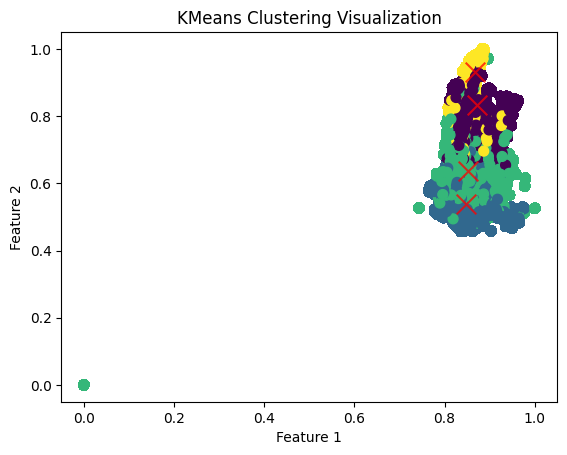

In [22]:
from sklearn.cluster import KMeans

# Apply KMeans
X_value = X.values
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Get cluster centers and predictions
centers = kmeans.cluster_centers_
y_kmeans = kmeans.predict(X_value)

# Plot the data and the clusters
plt.scatter(X_value[:, 0], X_value[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='x')
plt.title("KMeans Clustering Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

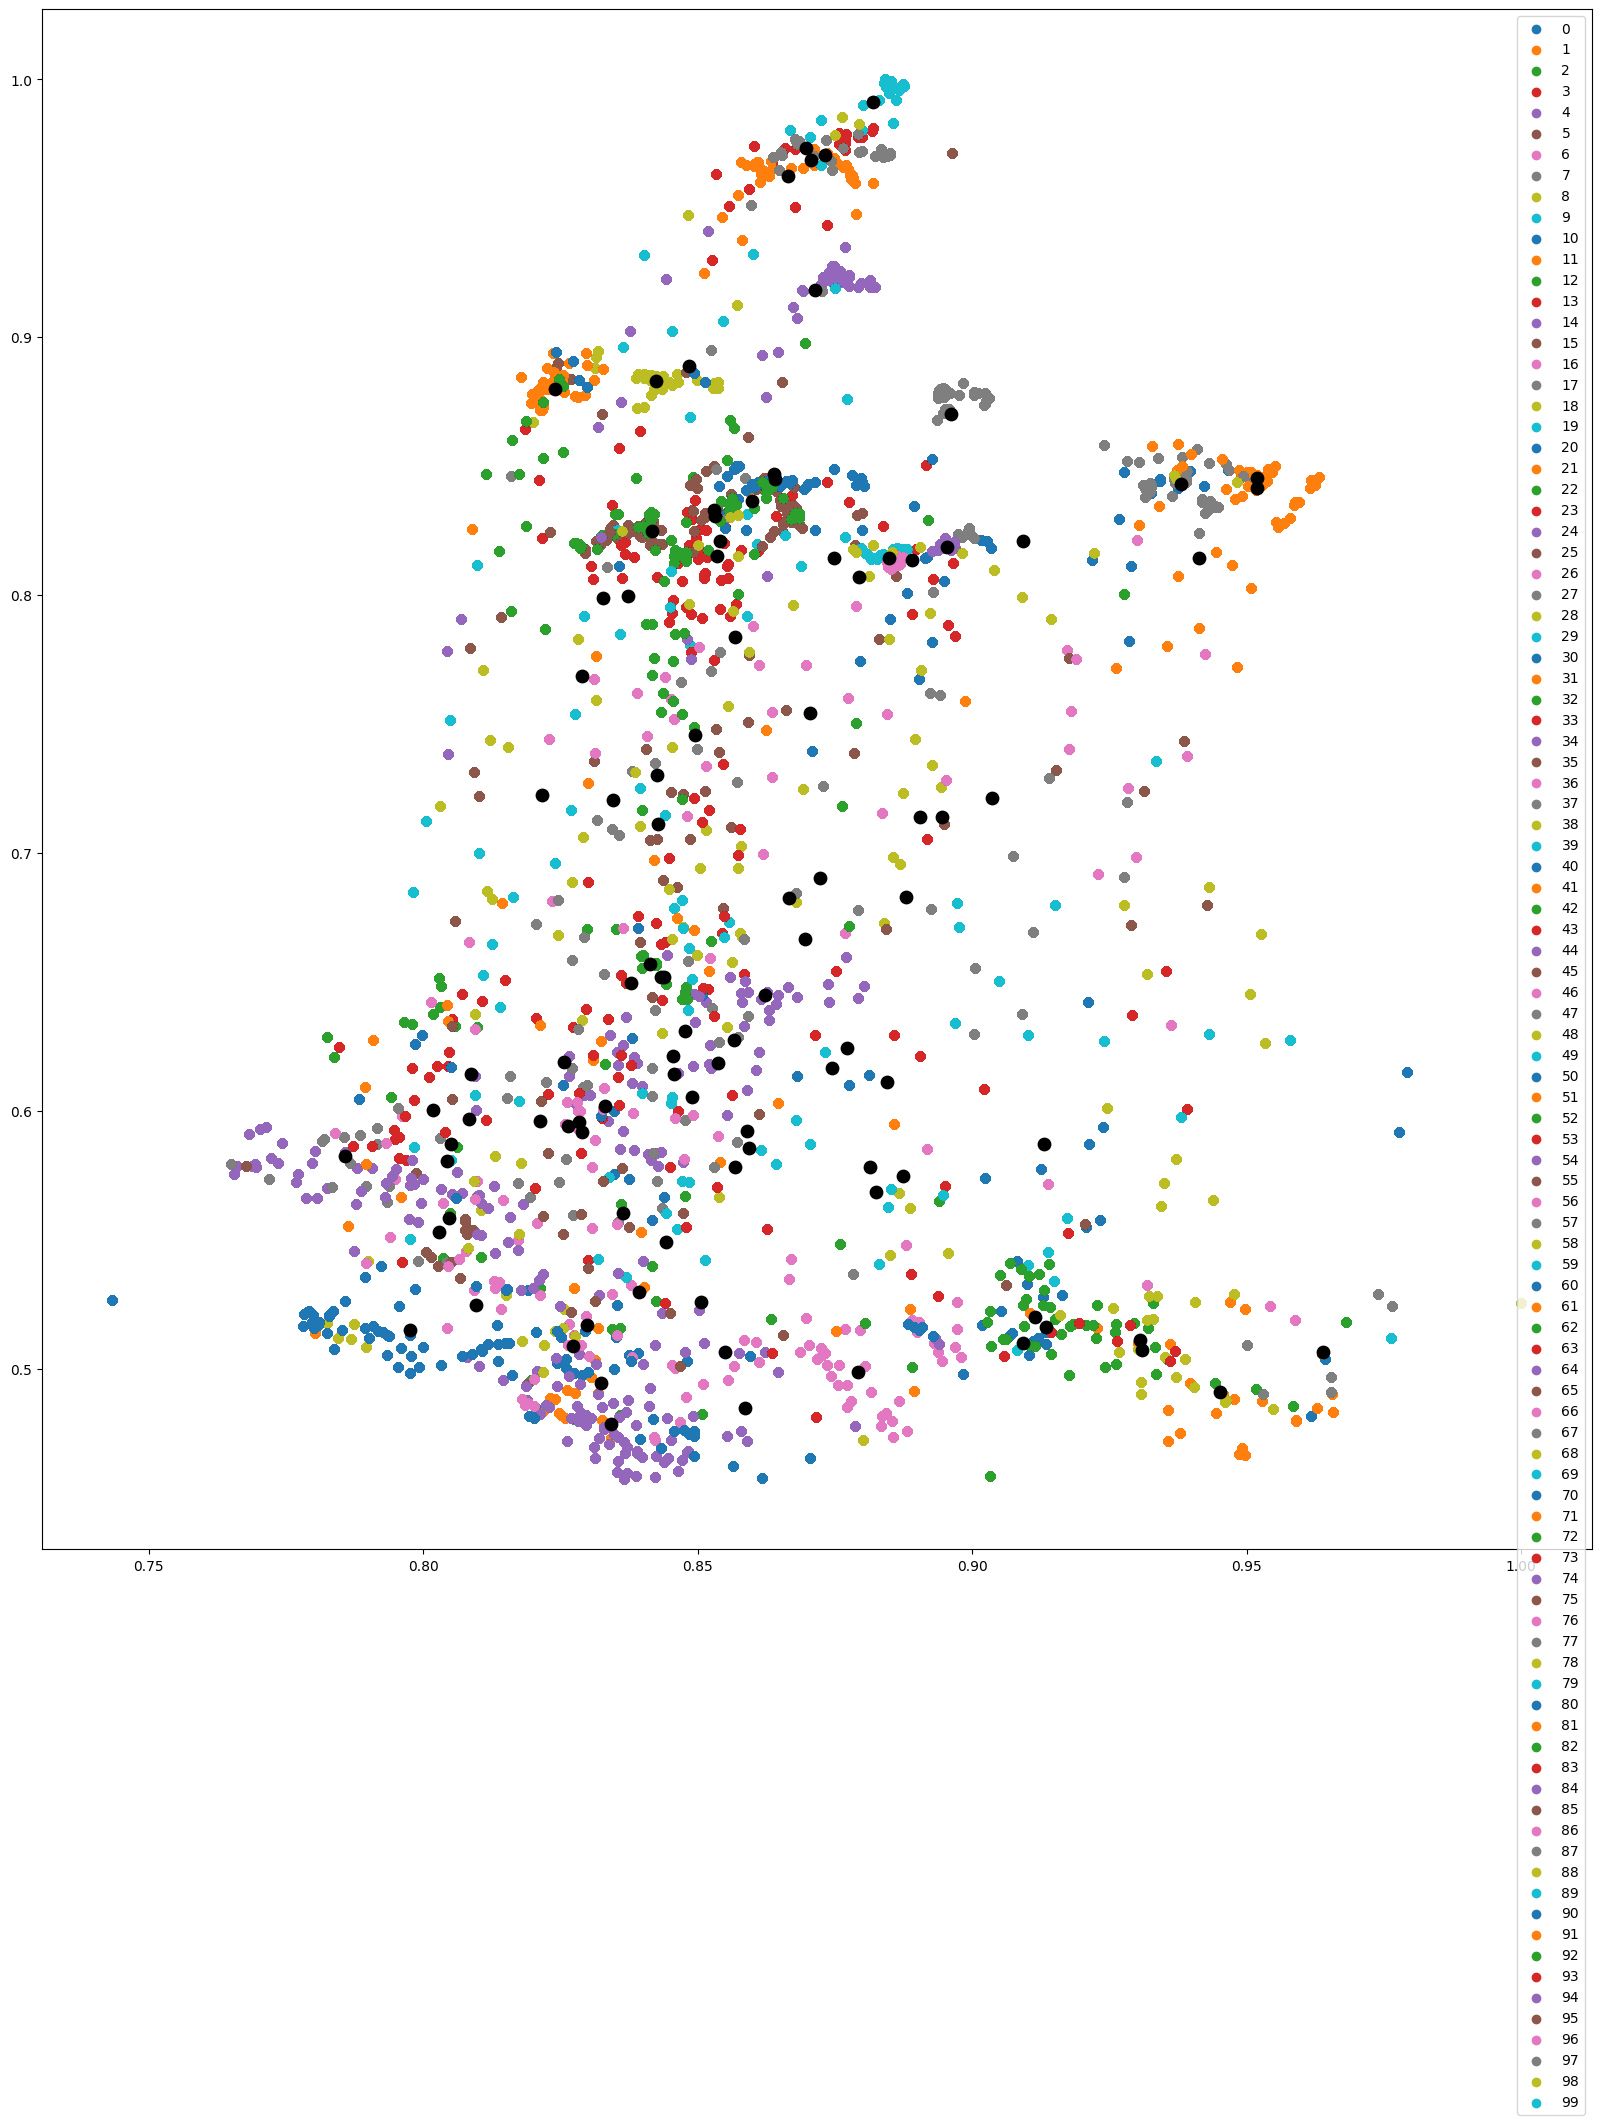

In [40]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

X_value = X.values
X_value = X_value[X_value[:, 0] != 0]
kmeans = KMeans(n_clusters = 100, init = 'k-means++', max_iter = 100, n_init = 10, random_state = 0)
# kmeans.fit(X)
X_normalized = normalize(X_value, axis=1)
label = kmeans.fit_predict(X_value)

#Getting the Centroids
centroids = kmeans.cluster_centers_
u_labels = np.unique(label)
 
# plotting the results:
plt.figure(figsize=(20, 20))

for i in u_labels:
    plt.scatter(X_value[label == i , 0] , X_value[label == i , 1] , label = i)
plt.scatter(centroids[:,0] , centroids[:,1] , s = 80, color = 'k')
plt.legend()
plt.show()

/home/osero/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


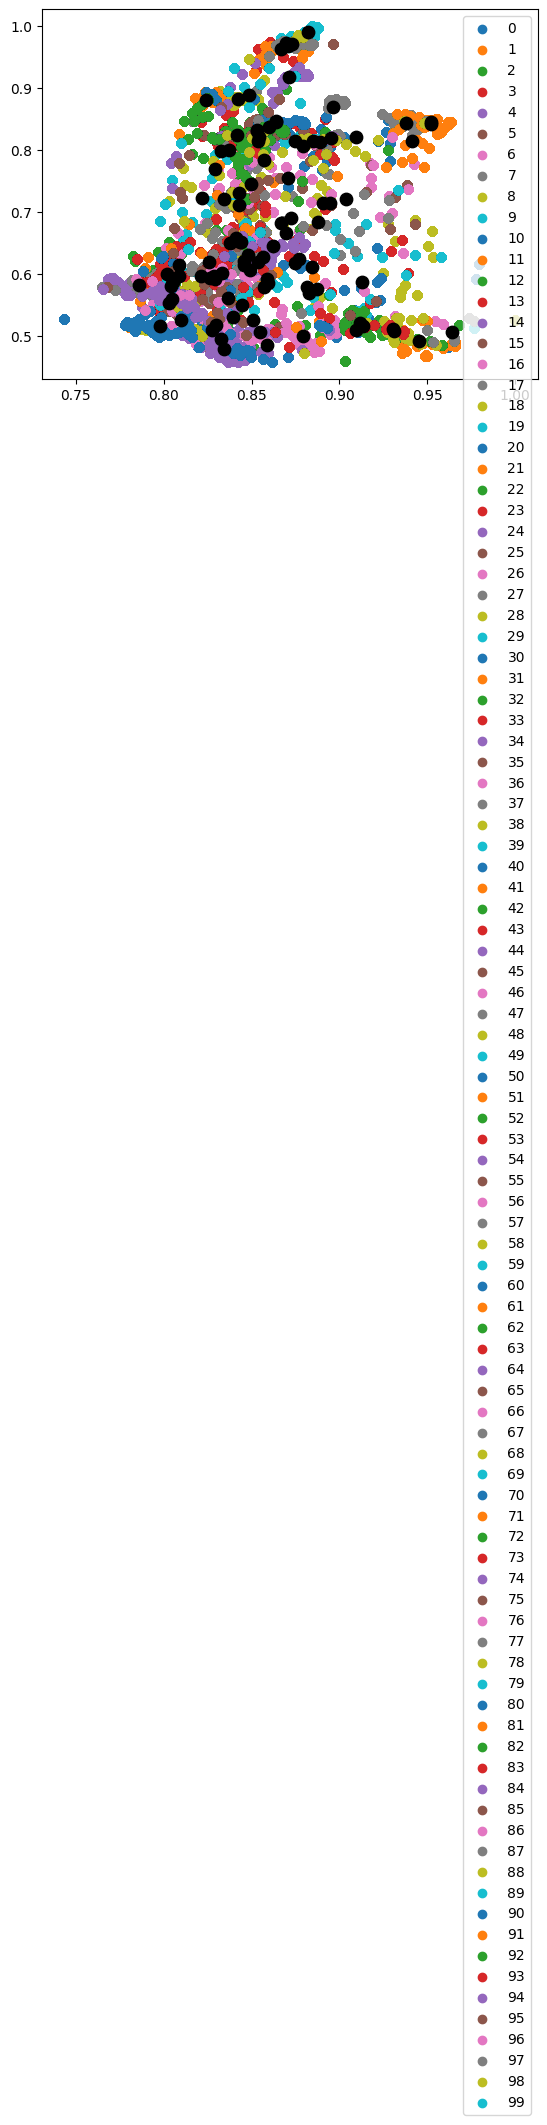

In [36]:
from sklearn.cluster import KMeans

X_value = X.values
X_value = X_value[X_value[:, 0] != 0]
kmeans = KMeans(n_clusters = 100, init = 'k-means++', max_iter = 100, n_init = 10, random_state = 0)
# kmeans.fit(X)
label = kmeans.fit_predict(X_value)

#Getting the Centroids
centroids = kmeans.cluster_centers_
u_labels = np.unique(label)
 
#plotting the results:
plt.figure(figsize=(20, 20))
for i in u_labels:
    plt.scatter(X_value[label == i , 0] , X_value[label == i , 1] , label = i)
plt.scatter(centroids[:,0] , centroids[:,1] , s = 80, color = 'k')
plt.legend()
plt.show()

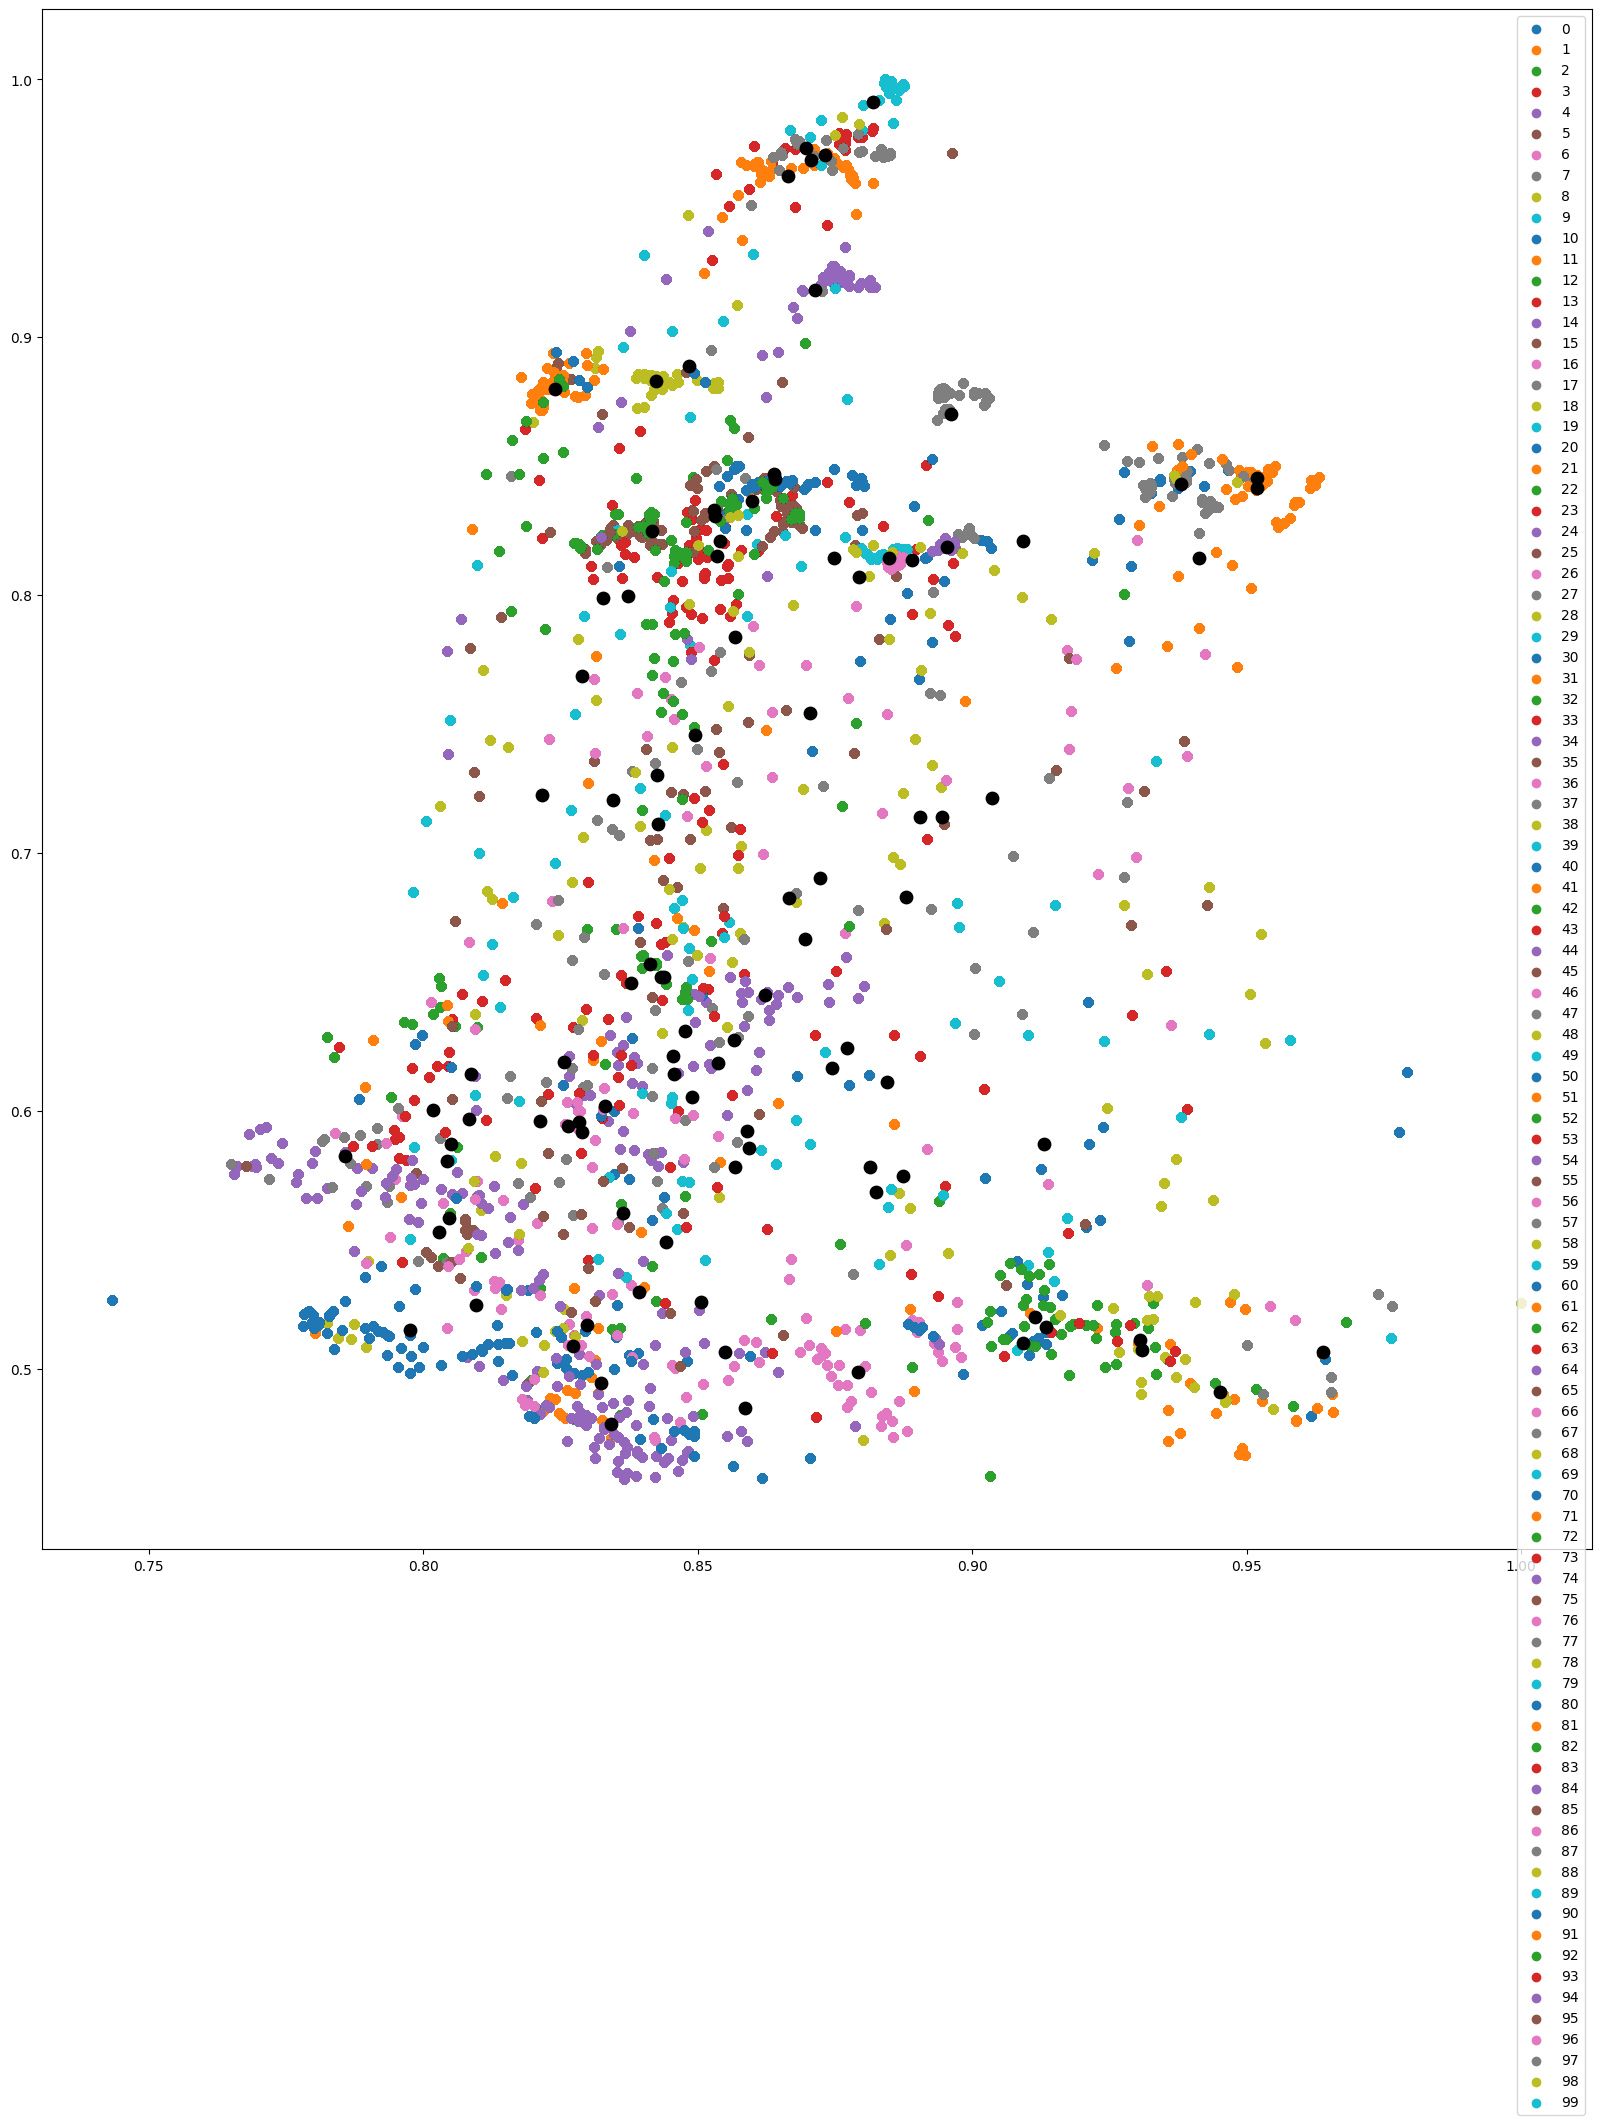

In [38]:
plt.figure(figsize=(20, 20))
for i in u_labels:
    plt.scatter(X_value[label == i , 0] , X_value[label == i , 1] , label = i)
plt.scatter(centroids[:,0] , centroids[:,1] , s = 80, color = 'k')
plt.legend()
plt.show()

In [21]:
# import matplotlib.pyplot as plt

# reduced_data = X.values
# kmeans = KMeans(init="k-means++", n_clusters=100, n_init=4)
# kmeans.fit(reduced_data)

# # Step size of the mesh. Decrease to increase the quality of the VQ.
# h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# # Plot the decision boundary. For that, we will assign a color to each
# x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
# y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
# xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# # Obtain labels for each point in mesh. Use last trained model.
# Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# # Put the result into a color plot
# Z = Z.reshape(xx.shape)
# plt.figure(1)
# plt.clf()
# plt.imshow(
#     Z,
#     interpolation="nearest",
#     extent=(xx.min(), xx.max(), yy.min(), yy.max()),
#     cmap=plt.cm.Paired,
#     aspect="auto",
#     origin="lower",
# )

# plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# # Plot the centroids as a white X
# centroids = kmeans.cluster_centers_
# plt.scatter(
#     centroids[:, 0],
#     centroids[:, 1],
#     marker="x",
#     s=169,
#     linewidths=3,
#     color="w",
#     zorder=10,
# )
# plt.title(
#     "K-means clustering on the digits dataset (PCA-reduced data)\n"
#     "Centroids are marked with white cross"
# )
# plt.xlim(x_min, x_max)
# plt.ylim(y_min, y_max)
# plt.xticks(())
# plt.yticks(())
# plt.show()

ValueError: X has 2 features, but KMeans is expecting 63 features as input.

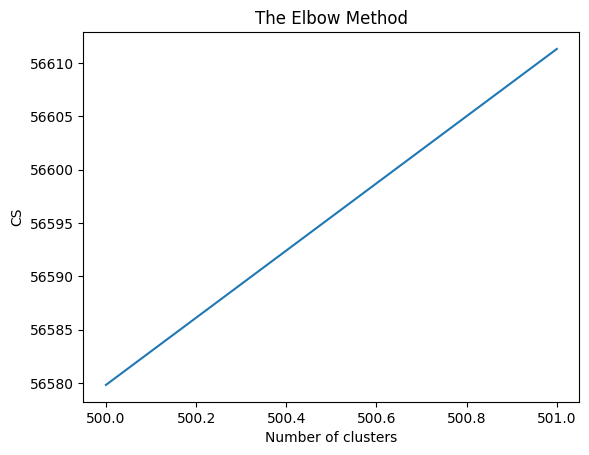

In [5]:
from sklearn.cluster import KMeans
cs = []
range_list = range(200, 400, 10)
for i in range_list:
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 100, n_init = 10, random_state = 0)
    X_normalized = normalize(X_value, axis=1)
    kmeans.fit(X)
    cs.append(kmeans.inertia_)
plt.plot(range_list, cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [ ]:

# import faiss
# import numpy as np

# # Convert pandas DataFrame X to a NumPy array and ensure it's float32
# X_np = X.to_numpy().astype(np.float32)

# cs = []
# for i in range(50, 60):
#     # Create the Faiss KMeans object
#     kmeans = faiss.Kmeans(d=X_np.shape[1], k=i, niter=300, nredo=10, seed=0, gpu=True)  # d: dimension of the data, k: number of clusters
#     kmeans.train(X_np)
    
#     # Append the final objective (inertia in scikit-learn) to cs list
#     cs.append(kmeans.obj[-1])

# plt.plot(range(50, 60), cs)
# plt.title('The Elbow Method')
# plt.xlabel('Number of clusters')
# plt.ylabel('CS')
# plt.show()